<a href="https://colab.research.google.com/github/darreneasler/MiniProject_02/blob/main/MiniProject02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
#Loading the Dataset

import numpy as np
import matplotlib as plt
import pandas as pd
import gdown
print("pandas", pd.__version__)
print()
print("numpy", np.__version__)
print()
print("matplotlib", plt.__version__)
print()

csv_id = "1y6ZzfQpY4rmplJ6DlJHTUNCV_68qtw_S"
url = f"https://drive.google.com/uc?id={csv_id}"
gdown.download(url, "insurance.csv", quiet=False)

print()
dataset = pd.read_csv("insurance.csv")
print(dataset.shape)
print()
dataset.head()

pandas 2.2.2

numpy 2.0.2

matplotlib 3.10.0



Downloading...
From: https://drive.google.com/uc?id=1y6ZzfQpY4rmplJ6DlJHTUNCV_68qtw_S
To: /content/insurance.csv
100%|██████████| 55.6k/55.6k [00:00<00:00, 51.8MB/s]


(1338, 7)



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [25]:
#Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

dataset['sex'] = le.fit_transform(dataset['sex'])
dataset['smoker'] = le.fit_transform(dataset['smoker'])
dataset['region'] = le.fit_transform(dataset['region'])
dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


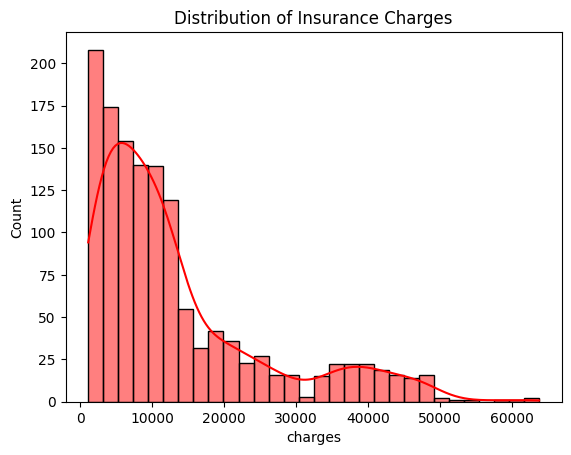

In [26]:
#Visualization 1: Charging Distribution

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(dataset["charges"], color = "red", kde = True)
plt.title("Distribution of Insurance Charges")
plt.show()

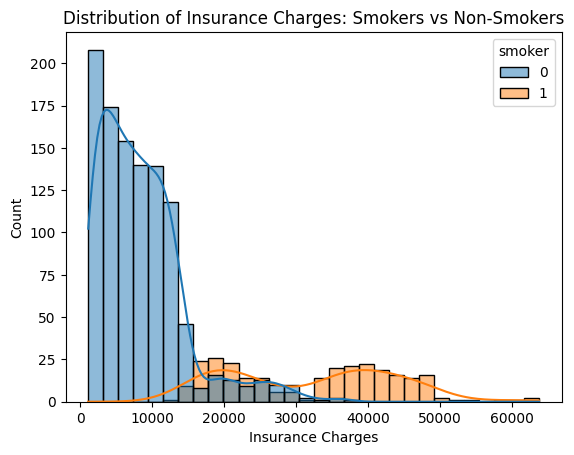

In [27]:
#Visualization 2: Impact of Smoking on Charges

sns.histplot(data=dataset, x="charges", hue="smoker", kde=True)

plt.title("Distribution of Insurance Charges: Smokers vs Non-Smokers")
plt.xlabel("Insurance Charges")
plt.ylabel("Count")
plt.show()


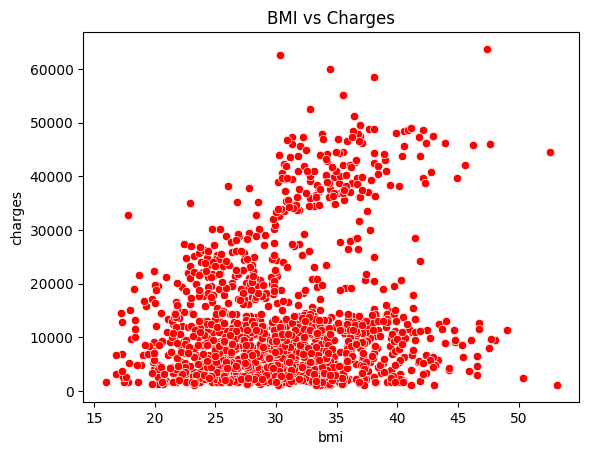

In [28]:
#Visualization 3: Impact of BMI on Charges

sns.scatterplot(x="bmi", y="charges", data=dataset, color = "red")
plt.title("BMI vs Charges")
plt.show()

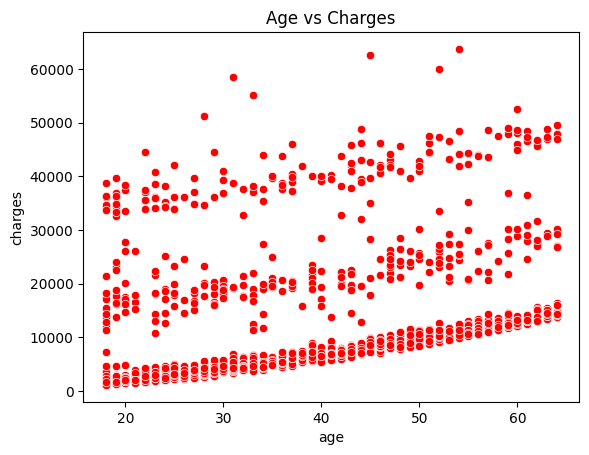

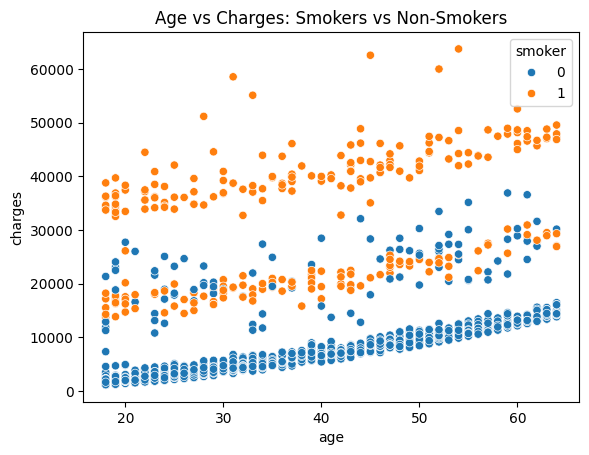

In [29]:
#Visualization 4: Impact of Age on Charges

sns.scatterplot(x="age", y="charges", data=dataset, color = "red")
plt.title("Age vs Charges")
plt.show()

sns.scatterplot(data=dataset, x="age", y="charges", hue="smoker")
plt.title("Age vs Charges: Smokers vs Non-Smokers")
plt.show()

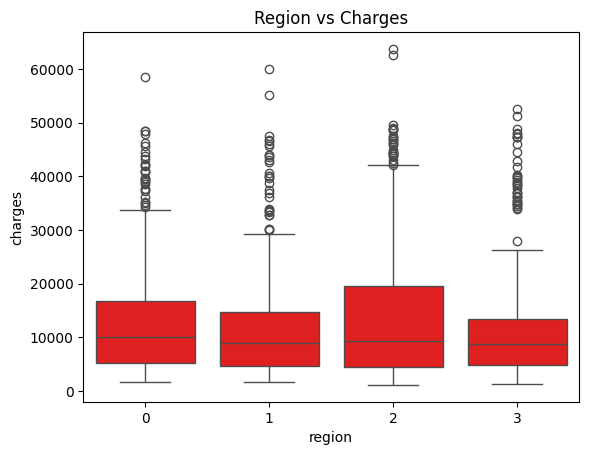

In [30]:
#Visualization 5: Impact of Region on Charges

sns.boxplot(x="region", y="charges", data=dataset, color = "red")
plt.title("Region vs Charges")
plt.show()


In [31]:
#Data Split for Models

dataset_cln = dataset.copy()

X = dataset_cln.drop("charges", axis=1)
Y = dataset_cln["charges"]

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)


(1070, 6)
(268, 6)
(1070,)
(268,)


In [32]:
#Evaluation Metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def eval_metrics(model, X_test, Y_test):
    predictions = model.predict(X_test)

    mae = mean_absolute_error(Y_test, predictions)
    mse = mean_squared_error(Y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(Y_test, predictions)

    print(f"MAE : {mae:.3f}")
    print(f"MSE : {mse:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²  : {r2:.3f}")

    return 0

In [33]:
#Simple Linear Regression

from sklearn.linear_model import LinearRegression

X_simple = dataset_cln[['smoker']]
X_train1, X_test1, Y_train1, Y_test1 = train_test_split(X_simple, Y, test_size=0.2, random_state=42)

model1 = LinearRegression()
model1.fit(X_train1, Y_train1)

eval_metrics(model1, X_test1, Y_test1)

MAE : 5625.811
MSE : 52745964.728
RMSE: 7262.642
R²  : 0.660


0

In [34]:
#Multivariable Linear Regression

model2 = LinearRegression()
model2.fit(X_train, Y_train)

eval_metrics(model2, X_test, Y_test)

MAE : 4186.509
MSE : 33635210.431
RMSE: 5799.587
R²  : 0.783


0

In [35]:
#Polynomial Regressions

from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model3 = LinearRegression()
model3.fit(X_poly, Y_train)

eval_metrics(model3, X_test_poly, Y_test)

print()

poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model3 = LinearRegression()
model3.fit(X_poly, Y_train)

eval_metrics(model3, X_test_poly, Y_test)

print()

poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model3 = LinearRegression()
model3.fit(X_poly, Y_train)

eval_metrics(model3, X_test_poly, Y_test)

MAE : 2730.316
MSE : 20530608.943
RMSE: 4531.072
R²  : 0.868

MAE : 2796.789
MSE : 21485238.633
RMSE: 4635.217
R²  : 0.862

MAE : 3128.596
MSE : 35435057.861
RMSE: 5952.735
R²  : 0.772


0

In [36]:
#Ridge Regression

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=0.1)
ridge.fit(X_train_scaled, Y_train)

eval_metrics(ridge, X_test_scaled, Y_test)


MAE : 4186.655
MSE : 33635862.374
RMSE: 5799.643
R²  : 0.783


0

In [37]:
#Lasso Regression

from sklearn.linear_model import Lasso

lasso = Lasso(alpha=10)
lasso.fit(X_train_scaled, Y_train)

eval_metrics(lasso, X_test_scaled, Y_test)

print(pd.DataFrame({"Feature": X.columns, "Coefficient": lasso.coef_}))

MAE : 4187.515
MSE : 33661029.238
RMSE: 5801.813
R²  : 0.783
    Feature  Coefficient
0       age  3607.307986
1       sex    -0.000000
2       bmi  2017.152341
3  children   507.254448
4    smoker  9546.232984
5    region  -290.438468


In [38]:
#Support Vector Regression

from sklearn.svm import SVR

svr = SVR(kernel="linear", C = 1000)
svr.fit(X_train_scaled, Y_train)

eval_metrics(svr, X_test_scaled, Y_test)
print()

svr2 = SVR(kernel="poly", degree=2, C = 1000, gamma = 0.1)
svr2.fit(X_train_scaled, Y_train)

eval_metrics(svr2, X_test_scaled, Y_test)
print()

svr3 = SVR(kernel="rbf", C = 1000, gamma = 0.1)
svr3.fit(X_train_scaled, Y_train)

eval_metrics(svr3, X_test_scaled, Y_test)

MAE : 3165.993
MSE : 43012080.884
RMSE: 6558.360
R²  : 0.723

MAE : 5371.077
MSE : 70024952.040
RMSE: 8368.091
R²  : 0.549

MAE : 2434.773
MSE : 30428021.734
RMSE: 5516.160
R²  : 0.804


0

In [39]:
#Decision Tree Regression Test

from sklearn.tree import DecisionTreeRegressor

depths = [2, 3, 4, 5, 6, 7, 8]

for depth in depths:

    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)

    tree.fit(X_train, Y_train)

    print(f"\nDepth = {depth}")

    eval_metrics(tree, X_test, Y_test)


Depth = 2
MAE : 3299.973
MSE : 26071833.628
RMSE: 5106.059
R²  : 0.832

Depth = 3
MAE : 2865.638
MSE : 22812669.852
RMSE: 4776.261
R²  : 0.853

Depth = 4
MAE : 2697.765
MSE : 21093484.005
RMSE: 4592.764
R²  : 0.864

Depth = 5
MAE : 2919.197
MSE : 26240611.466
RMSE: 5122.559
R²  : 0.831

Depth = 6
MAE : 2884.978
MSE : 27752329.220
RMSE: 5268.048
R²  : 0.821

Depth = 7
MAE : 2942.094
MSE : 31024152.512
RMSE: 5569.933
R²  : 0.800

Depth = 8
MAE : 2839.527
MSE : 33035783.720
RMSE: 5747.676
R²  : 0.787


In [40]:
#Decision Tree Regression

best_tree = DecisionTreeRegressor(
    max_depth=4,
    random_state=42
)

best_tree.fit(X_train, Y_train)

eval_metrics(best_tree, X_test, Y_test)



MAE : 2697.765
MSE : 21093484.005
RMSE: 4592.764
R²  : 0.864


0

In [42]:
#Expensive Flags

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix


median = dataset["charges"].median()

dataset["expensive"] = (dataset["charges"] > median).astype(int)

new_X = dataset.drop(["charges", "expensive"], axis=1)
new_Y = dataset["expensive"]

new_X = pd.get_dummies(new_X, columns=["sex", "smoker", "region"])

new_X_train, new_X_test, new_Y_train, new_Y_test = train_test_split(new_X, new_Y, test_size=0.2, random_state=42, stratify=new_Y)
new_X_train = scaler.fit_transform(new_X_train)
new_X_test = scaler.transform(new_X_test)

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(new_X_train)
X_test_poly = poly.transform(new_X_test)

poly_model = LogisticRegression(max_iter=10000)
poly_model.fit(X_train_poly, new_Y_train)

predictions = poly_model.predict(X_test_poly)

cm = confusion_matrix(new_Y_test, predictions)

print(f"Accuracy: {accuracy_score(new_Y_test, predictions):.3f}")
print()
print(f"Precision: {precision_score(new_Y_test, predictions):.3f}")
print()
print(f"Recall: {recall_score(new_Y_test, predictions):.3f}")
print()
print(cm)



Accuracy: 0.933

Precision: 0.960

Recall: 0.903

[[129   5]
 [ 13 121]]
